In [5]:
from pathlib import Path
DATA_DIR = Path('../data/raw')

import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
%matplotlib inline

In [2]:
# старый план
df = pd.read_excel(DATA_DIR / "Данные по Плану 1 ПИН\\Дисц 1 и 2 семестра  ПИН_31-36 22-23.xlsx", header=0)
OMA_res_1 = df[' оМА_итог'].dropna().tolist()
n = len(OMA_res_1)
n

143

In [21]:
# новый план
df2 = pd.read_excel(DATA_DIR / "Данные по Плану 2 ПИН\\ОМА ПИН-21-27 1 сем 23-24.xlsx", header=0)
OMA_res_2 = df2['Unnamed: 12'][4:].tolist()
# нормировка
OMA_res_2 = [x/100 for x in OMA_res_2]
n2 = len(OMA_res_2)
n2

140

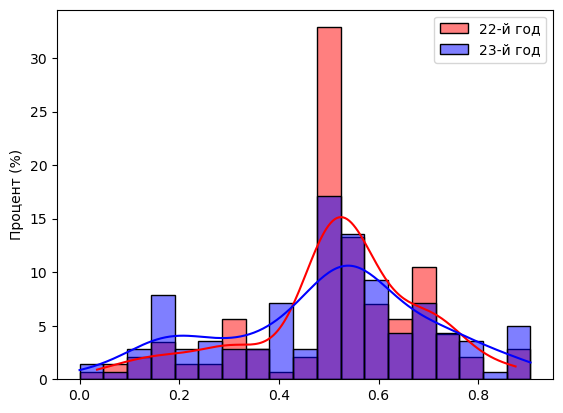

In [ ]:
bins = np.linspace(min(np.concatenate([OMA_res_1, OMA_res_2])),
                  max(np.concatenate([OMA_res_1, OMA_res_2])),
                  20)

# Гистограммы с одинаковыми бинами
sns.histplot(OMA_res_1, bins=bins, kde=True, stat='percent', color='red', label='22-й год')
sns.histplot(OMA_res_2, bins=bins, kde=True, stat='percent', color='blue', label='23-й год')
plt.legend()
plt.ylabel('Процент (%)')
plt.show()

In [7]:
print("Коэффициент ассиметрии для плана 1: ", sts.skew(OMA_res_1))
print("Коэффициент ассиметрии для плана 2: ", sts.skew(OMA_res_2))

Коэффициент ассиметрии для плана 1:  -0.6271402378913203
Коэффициент ассиметрии для плана 2:  -0.32643770575745734


In [8]:
print("Медиана для плана 1: ",(np.median(OMA_res_1)))
print("Медиана для плана 2: ",(np.median(OMA_res_2)))

Медиана для плана 1:  0.513
Медиана для плана 2:  0.5155000000000001


Проверим гипотезу о равенстве мат ожиданий оценок

In [ ]:
def bootstrap_mean_diff_test(X, Y, n_iterations=100000, alternative='two-sided'):

    X = np.array(X)
    Y = np.array(Y)
    observed_diff = np.mean(X) - np.mean(Y)
    pooled_data = np.concatenate([X, Y])
    bootstrap_diffs = np.zeros(n_iterations)

    #np.random.seed(42)  # для воспроизводимости

    for i in range(n_iterations):
        # Генерируем новые выборки с заменой из объединенных данных
        X_new = np.random.choice(pooled_data, size=len(X), replace=True)
        Y_new = np.random.choice(pooled_data, size=len(Y), replace=True)
        bootstrap_diffs[i] = np.mean(X_new) - np.mean(Y_new)

    # Вычисляем p-value в зависимости от альтернативы
    if alternative == 'two-sided':
        p_value = (np.sum(np.abs(bootstrap_diffs) >= np.abs(observed_diff))) / n_iterations
    elif alternative == 'greater':
        p_value = (np.sum(bootstrap_diffs >= observed_diff)) / n_iterations
    elif alternative == 'less':
        p_value = (np.sum(bootstrap_diffs <= observed_diff)) / n_iterations
    else:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")

    return p_value


In [10]:
mean_OMA1 = np.mean(OMA_res_1)
mean_OMA2 = np.mean(OMA_res_2)

print(f"Математическое ожидание OMA_res_1: {mean_OMA1:.4f}")
print(f"Математическое ожидание OMA_res_2: {mean_OMA2:.4f}")

p_value = bootstrap_mean_diff_test(OMA_res_1, OMA_res_2)
print(f"p-значение: {p_value:.4f}")

Математическое ожидание OMA_res_1: 0.5162
Математическое ожидание OMA_res_2: 0.4954
 p-значение: 0.3542


Гипотезу о равенстве математических ожиданий не отвергаем

Интересно также посмотреть в каком году вероятность не получить зачет больше (назовем вероятнсти p1 и p2), для этого используем метод пропорций

In [9]:
not_passed = [x for x in OMA_res_1 if x < 0.5 ]
passed = [x for x in OMA_res_1 if x >= 0.5]
not_passed2 = [x for x in OMA_res_2 if x < 0.5 ]
passed2 = [x for x in OMA_res_2 if x >= 0.5]
print("Количество несдавших в 22-м году", len(not_passed))
print("Количество несдавших в 23-м году", len(not_passed2))

Количество несдавших в 22-м году 31
Количество несдавших в 23-м году 49


Примем H0: p1 = p2, при альтернативной p1 < p2 (вероятность получить "незачет" в 22-м году меньше, чем в 23-м)

In [10]:
from statsmodels.stats.proportion import proportions_ztest

# Z-тест для равенства пропорций
counts = np.array([len(not_passed), len(not_passed2)])  # Число "успехов" в каждой выборке
nobs = np.array([n, n2])     # Общие размеры выборок
z_stat, p_value = proportions_ztest(counts, nobs, alternative='smaller')
print(f"Z-статистика: {z_stat:.4f}, p-value: {p_value:.4f}")

Z-статистика: -2.4882, p-value: 0.0064


Понятно, что гипотезу H0 стоит отвергнуть в пользу альтернативной. Очевидно, что в 22-м году "двойки" в итоге получали реже

Часто случайные выбросы могут серьезно изменять общую картину. Поэтому мы рассмотрим усредненные данные, убирая часть данных, невходящих в требуемый межквартильный размах. И повторим анализ

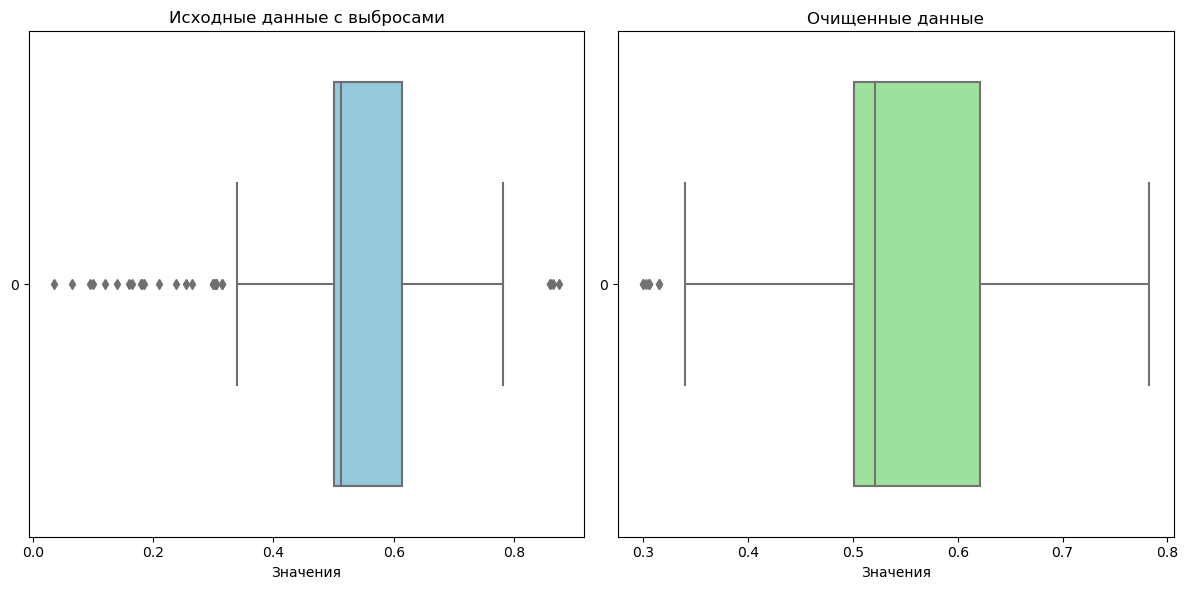

Удалено выбросов: 19
Осталось точек: 124


In [19]:
%run ../src/iqr.ipynb

cleaned_OMA_1 = remove_outliers_iqr_0(OMA_res_1,  k=2.0)

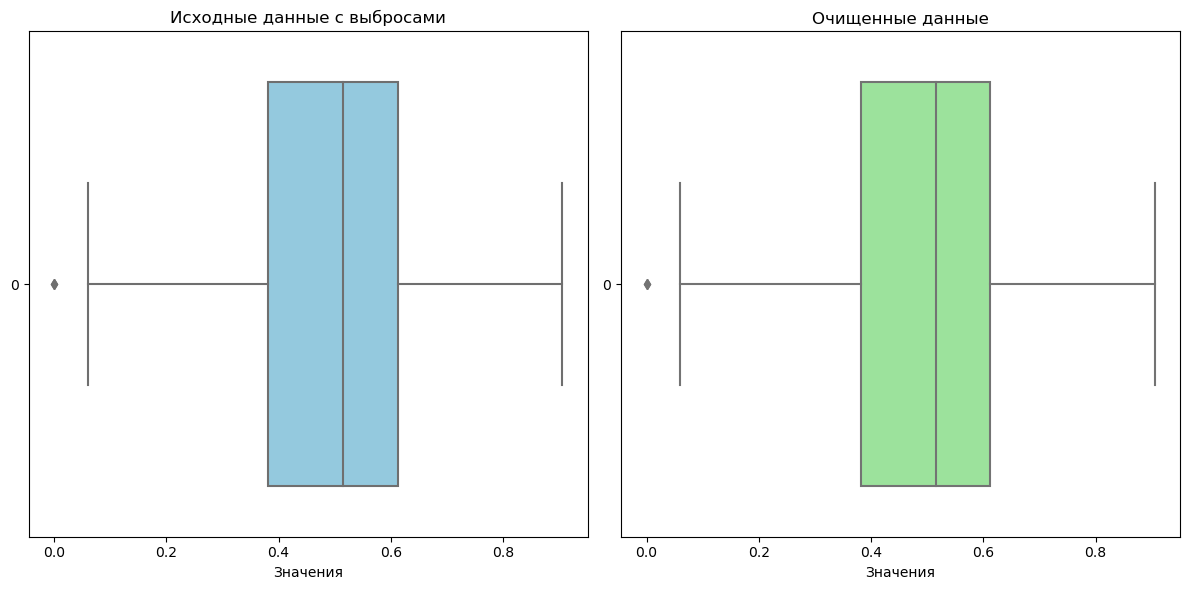

Удалено выбросов: 0
Осталось точек: 140


In [22]:
cleaned_OMA_2 = remove_outliers_iqr_0(OMA_res_2, k=2.0)

Как видно, во втором случае выбросов было значительно меньше. А в первом были убраны многие студенты с количеством баллов <30

In [14]:
print("Выборочная дисперсия сначала ", np.var(OMA_res_1))
print("Выборочная дисперсия после фильтрации ", np.var(cleaned_OMA_1))

Выборочная дисперсия сначала  0.029137380144750355
Выборочная дисперсия после фильтрации  0.012756204616285117


После фильтрации дисперсия, как ожидалось, уменьшилась

In [18]:
mean_OMA1 = np.mean(cleaned_OMA_1)
mean_OMA2 = np.mean(cleaned_OMA_2)

print(f"Матожидание OMA_res_1: {mean_OMA1:.4f}")
print(f"Матожидание OMA_res_2: {mean_OMA2:.4f}")

p_value = bootstrap_mean_diff_test(cleaned_OMA_1, cleaned_OMA_2, alternative='greater')
print(f"p-значение: {p_value:.4f}")

Матожидание OMA_res_1: 0.5481
Матожидание OMA_res_2: 0.4954
p-значение: 0.0064


Видно, что значение p-value уменьшилось, в случае фильтрованных данных принимаем альтернативную гипотезу: математическое ожидание больше у первой группы

In [15]:
print("Медиана для плана 1: ",(np.median(cleaned_OMA_1)))
print("Медиана для плана 2: ",(np.median(cleaned_OMA_2)))

Медиана для плана 1:  0.52095
Медиана для плана 2:  0.5155000000000001


Медианы остались также примерно на одном уровне

In [16]:
not_passed = [x for x in cleaned_OMA_1 if x < 0.5 ]
passed = [x for x in cleaned_OMA_1 if x >= 0.5]
not_passed2 = [x for x in cleaned_OMA_2 if x < 0.5 ]
passed2 = [x for x in cleaned_OMA_2 if x >= 0.5]
print("Количество несдавших в 22-м году", len(not_passed))
print("Количество несдавших в 23-м году", len(not_passed2))

Количество несдавших в 22-м году 16
Количество несдавших в 23-м году 49


In [17]:
# Z-тест для равенства пропорций
n = len(cleaned_OMA_1)
n2 = len(cleaned_OMA_2)
counts = np.array([len(not_passed), len(not_passed2)])  # Число "успехов" в каждой выборке
nobs = np.array([n, n2])     # Общие размеры выборок
z_stat, p_value = proportions_ztest(counts, nobs, alternative='smaller')
print(f"Z-статистика: {z_stat:.4f}, p-value: {p_value:.8f}")

Z-статистика: -4.1593, p-value: 0.00001596


Очевидно, что вероятность не сдать ОМА в 22-м году сильно ниже, чем вероятность не сдать их в 23-м

Проведем аналогичные тесты для курса алегбры и геометрии первого семестра

In [20]:
AG_res_1 = df['АиГ_итог'].dropna().tolist()
n = len(AG_res_1)
n

143

In [ ]:
path_plan2_ag = DATA_DIR / "Данные по Плану 2 ПИН/АиГ ПИН-21-27 1 сем 23-24.xlsx"
df3 = pd.read_excel(path_plan2_ag, header=0)
AG_res_2 = df3['Unnamed: 8'].dropna().tolist()[2:]
AG_res_2 = [x / 100 for x in AG_res_2]
n2 = len(AG_res_2)
n2

139

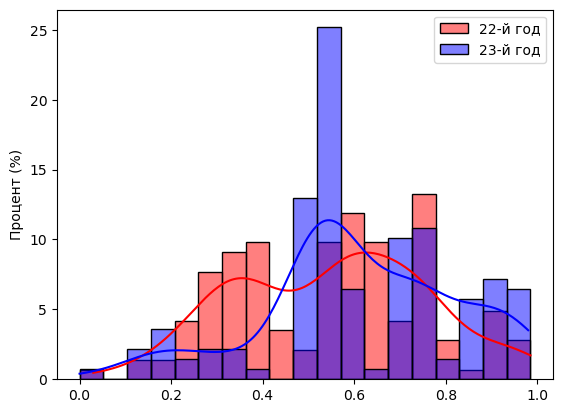

In [ ]:
bins = np.linspace(min(np.concatenate([AG_res_1, AG_res_2])),
                  max(np.concatenate([AG_res_1, AG_res_2])),
                  20)

# Гистограммы с одинаковыми бинами
sns.histplot(AG_res_1, bins=bins, kde=True, stat='percent', color='red', label='22-й год')
sns.histplot(AG_res_2, bins=bins, kde=True, stat='percent', color='blue', label='23-й год')
plt.legend()
plt.ylabel('Процент (%)')
plt.show()

In [23]:
print("Медиана для плана 1: ",(np.median(AG_res_1)))
print("Медиана для плана 2: ",(np.median(AG_res_2)))

Медиана для плана 1:  0.573
Медиана для плана 2:  0.57


In [24]:
mean_AG1 = np.mean(AG_res_1)
mean_AG2 = np.mean(AG_res_2)

print(f"Математическое ожидание AG_res_1: {mean_AG1:.4f}")
print(f"Математическое ожидание AG_res_2: {mean_AG2:.4f}")

p_value = bootstrap_mean_diff_test(AG_res_1, AG_res_2, alternative='two-sided')
print(f"p-значение: {p_value:.4f}")

Математическое ожидание AG_res_1: 0.5486
Математическое ожидание AG_res_2: 0.6146
p-значение: 0.0094


Можно считать, что во втором случае средняя оценка больше, чем в первом 

In [26]:
not_passed = [x for x in AG_res_1 if x < 0.5 ]
passed = [x for x in AG_res_1 if x >= 0.5]
not_passed2 = [x for x in AG_res_2 if x < 0.5 ]
passed2 = [x for x in AG_res_2 if x >= 0.5]
print("Количество несдавших в 22-м году", len(not_passed))
print("Количество несдавших в 23-м году", len(not_passed2))

Количество несдавших в 22-м году 54
Количество несдавших в 23-м году 18


In [27]:
# Z-тест для равенства пропорций
counts = np.array([len(not_passed), len(not_passed2)])  # Число "успехов" в каждой выборке
nobs = np.array([n, n2])     # Общие размеры выборок
z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')
print(f"Z-статистика: {z_stat:.4f}, p-value: {p_value:.4f}")

Z-статистика: 4.7775, p-value: 0.0000


В случае с АиГ ситуация обратная. Принимаем гипотезу, что в 23-м году "двойки" в итоге получали реже

Применим фильтрацию данных

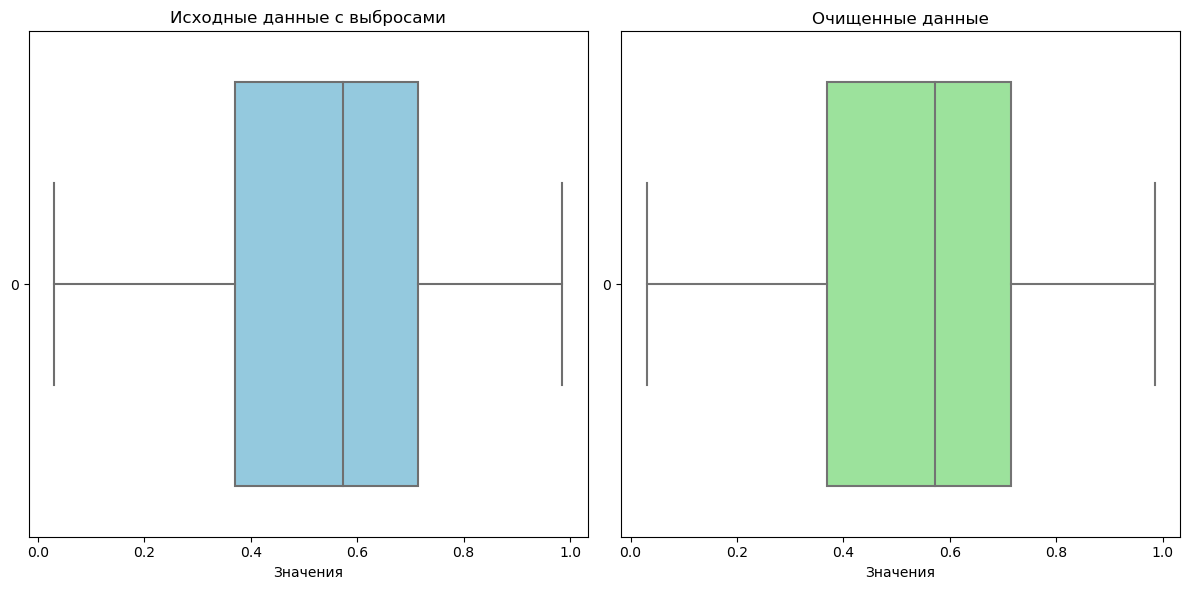

Удалено выбросов: 0
Осталось точек: 143


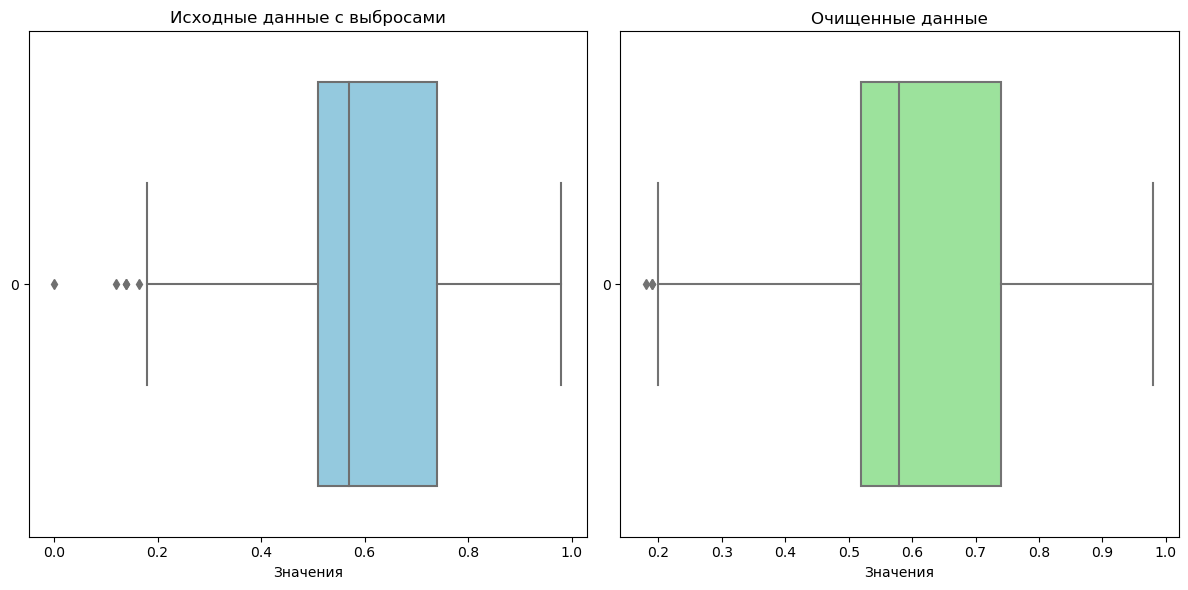

Удалено выбросов: 5
Осталось точек: 134


In [28]:
cleaned_AG_1 = remove_outliers_iqr(AG_res_1, k=1.5)
cleaned_AG_2 = remove_outliers_iqr(AG_res_2, k=1.5)

In [29]:
print("Выборочная дисперсия сначала ", np.var(AG_res_2))
print("Выборочная дисперсия после фильтрации ", np.var(cleaned_AG_2))

Выборочная дисперсия сначала  0.044603827441643804
Выборочная дисперсия после фильтрации  0.036401408999777236


In [30]:
not_passed = [x for x in cleaned_AG_1 if x < 0.5 ]
passed = [x for x in cleaned_AG_1 if x >= 0.5]
not_passed2 = [x for x in cleaned_AG_2 if x < 0.5 ]
passed2 = [x for x in cleaned_AG_2 if x >= 0.5]
print("Количество несдавших в 22-м году", len(not_passed))
print("Количество несдавших в 23-м году", len(not_passed2))

Количество несдавших в 22-м году 54
Количество несдавших в 23-м году 13


In [31]:
# Z-тест для равенства пропорций
n = len(cleaned_AG_1)
n2 = len(cleaned_AG_2)
counts = np.array([len(not_passed), len(not_passed2)])  # Число "успехов" в каждой выборке
nobs = np.array([n, n2])     # Общие размеры выборок
z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')
print(f"Z-статистика: {z_stat:.4f}, p-value: {p_value:.8f}")

Z-статистика: 5.4502, p-value: 0.00000003


После удаления выбросов ситуация изменилась незначительно

В ходе проведенного анализа было выяснено, что поступившие в 22-м году лучше сдавали ОМА, а поступившие в 23-м — АиГ. Это может быть связано, например, с различием преподавателей семинаристов. Проверим результаты экзаменов

In [26]:
OMA_exam_1 = df[' оМА_экз'].dropna().tolist()
OMA_exam_2 = df2['Unnamed: 10'].dropna().tolist()[2:]
OMA_exam_2 = [x / 34 for x in OMA_exam_2 if x != 'н']


In [27]:
mean_1 = np.mean(OMA_exam_1)
mean_2 = np.mean(OMA_exam_2)

print(f"Математическое ожидание OMA_1: {mean_1:.4f}")
print(f"Математическое ожидание OMA_2: {mean_2:.4f}")

p_value = bootstrap_mean_diff_test(OMA_exam_1, OMA_exam_2, alternative='two-sided')
print(f"p-значение: {p_value:.4f}")

Математическое ожидание OMA_1: 0.4305
Математическое ожидание OMA_2: 0.3350
p-значение: 0.0053


Результаты экзаменов по ОМА значительно лучше у первой группы

In [28]:
AG_exam_1 = df['АиГ_итог'].dropna().tolist()
mean_1 = np.mean(AG_exam_1)

AG_exam_2 = df3['Unnamed: 7'].dropna().tolist()[3:]
AG_exam_2 = [x / 40 for x in AG_exam_2 if x != 'н']

mean_2 = np.mean(AG_exam_2)

print(f"Математическое ожидание AиГ_1: {mean_1:.4f}")
print(f"Математическое ожидание АиГ_2: {mean_2:.4f}")

p_value = bootstrap_mean_diff_test(AG_exam_1, AG_exam_2, alternative='two-sided')
print(f"p-значение: {p_value:.4f}")

Математическое ожидание AиГ_1: 0.5486
Математическое ожидание АиГ_2: 0.5793
p-значение: 0.3086


Результаты экзаменов по АиГ незначительно лучше у второй группы

#### Вывод:
В ходе проведенного анализа было выяснено, что поступившие в 22-м году лучше сдавали ОМА, а поступившие в 23-м — АиГ. Такая ситуация является необычной. Как оказалось, это связано с тем, что по лектор по предмету АиГ был заменен на менее требовательного, так что в дальнейшем для учета начальных уровней в анализе мы будем использовать только результаты по ОМА